# Feature Engineering & Model Assessment

Exploratory analysis of the Day-Ahead vs. Imbalance spread and its relationship to fundamental grid features.
This notebook profiles the target variable used by the virtual trading strategy and examines which pre-auction features carry predictive signal.

In [ ]:
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)

# --- Analysis period ---
ANALYSIS_START = "2017-01-01"
ANALYSIS_END   = "2018-01-01"

proc = pd.read_parquet("../data/processed/processed_data.parquet")
proc["time"] = pd.to_datetime(proc["time"], utc=True)
proc = proc.sort_values("time").reset_index(drop=True)

mask = (proc["time"] >= ANALYSIS_START) & (proc["time"] < ANALYSIS_END)
proc = proc[mask].reset_index(drop=True)

proc["spread"] = proc["system_sell_price"] - proc["day_ahead_price"]

if "wind_fc_da_d1_10h30" in proc.columns and "demand_fc_da_d1_10h30" in proc.columns:
    proc["auction_residual_load"] = proc["demand_fc_da_d1_10h30"] - proc["wind_fc_da_d1_10h30"]

# --- Build lag & drift features for downstream sections ---
FEATURE_COLS = [
    "wind_fc_da_d1_10h30",
    "demand_fc_da_d1_10h30",
    "auction_residual_load",
    "wind_auction_drift",
    "day_ahead_price_lag48",
    "day_ahead_price_lag96",
    "system_sell_price_lag48",
    "system_sell_price_lag96",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

if "wind_fc_da_d1_07h" in proc.columns and "wind_fc_da_d1_10h30" in proc.columns:
    proc["wind_auction_drift"] = proc["wind_fc_da_d1_10h30"] - proc["wind_fc_da_d1_07h"]

for col in ["day_ahead_price", "system_sell_price"]:
    if col in proc.columns:
        proc[f"{col}_lag48"] = proc[col].shift(48)
        proc[f"{col}_lag96"] = proc[col].shift(96)

local_time = proc["time"].dt.tz_convert("Europe/London")
hour = local_time.dt.hour + local_time.dt.minute / 60
dow = local_time.dt.dayofweek

proc["hour_sin"] = np.sin(2 * np.pi * hour / 24)
proc["hour_cos"] = np.cos(2 * np.pi * hour / 24)
proc["dow_sin"]  = np.sin(2 * np.pi * dow / 7)
proc["dow_cos"]  = np.cos(2 * np.pi * dow / 7)

print(f"Dataset: {proc['time'].min().date()} to {proc['time'].max().date()}")
print(f"Half-hour periods: {len(proc):,}")
print(f"Columns: {len(proc.columns)}")

---
## Section 1 — The Target Variable

The virtual strategy profits from the spread between the Day-Ahead auction price and the imbalance settlement price (SSP):

$$\text{Spread} = \text{SSP} - \text{DA Price}$$

Understanding the statistical properties of this spread is essential: heavy tails and skewness determine whether mean-based models are appropriate, or whether the strategy must account for extreme deviations that dominate P&L.

=== Spread Distribution: SSP − DA Price (GBP/MWh) ===

  Count:       17,756
  Mean:        -0.19
  Median:      -4.49
  Std Dev:     27.79
  Min:         -251.5
  Max:         +915.6
  Skewness:    +5.756
  Ex. Kurtosis:+116.669

  Kurtosis of +116.7 confirms heavy tails — extreme spread events
  occur far more often than a normal distribution would predict.


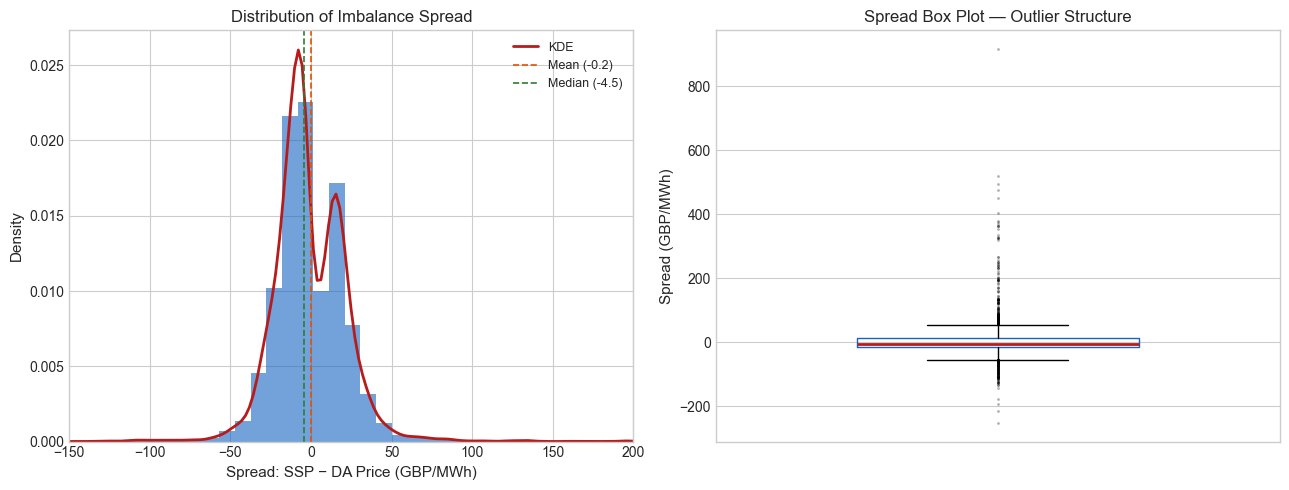

In [2]:
spread = proc["spread"].dropna()

skewness = stats.skew(spread)
kurt = stats.kurtosis(spread)

print("=== Spread Distribution: SSP − DA Price (GBP/MWh) ===\n")
print(f"  Count:       {len(spread):,}")
print(f"  Mean:        {spread.mean():+.2f}")
print(f"  Median:      {spread.median():+.2f}")
print(f"  Std Dev:     {spread.std():.2f}")
print(f"  Min:         {spread.min():+.1f}")
print(f"  Max:         {spread.max():+.1f}")
print(f"  Skewness:    {skewness:+.3f}")
print(f"  Ex. Kurtosis:{kurt:+.3f}")
print()
if abs(kurt) > 3:
    print(f"  Kurtosis of {kurt:+.1f} confirms heavy tails — extreme spread events")
    print("  occur far more often than a normal distribution would predict.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(spread, bins=120, density=True, alpha=0.6, color="#1565C0", edgecolor="none")
spread.plot.kde(ax=axes[0], linewidth=2, color="#B71C1C", label="KDE")
axes[0].axvline(spread.mean(), color="#E65100", linestyle="--", linewidth=1.2, label=f"Mean ({spread.mean():+.1f})")
axes[0].axvline(spread.median(), color="#2E7D32", linestyle="--", linewidth=1.2, label=f"Median ({spread.median():+.1f})")
axes[0].set_xlabel("Spread: SSP − DA Price (GBP/MWh)", fontsize=11)
axes[0].set_ylabel("Density", fontsize=11)
axes[0].set_title("Distribution of Imbalance Spread", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_xlim(-150, 200)

axes[1].boxplot(spread, vert=True, widths=0.5,
                boxprops=dict(color="#1565C0"),
                medianprops=dict(color="#B71C1C", linewidth=2),
                flierprops=dict(marker=".", markersize=2, alpha=0.3))
axes[1].set_ylabel("Spread (GBP/MWh)", fontsize=11)
axes[1].set_title("Spread Box Plot — Outlier Structure", fontsize=12)
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

---
## Section 2 — Feature Correlation

We examine the core grid fundamentals available before the 11:00 AM EPEX auction and their relationship to the target spread:

| Feature | Description |
|---|---|
| **`wind_fc_da_d1_10h30`** | Wind generation forecast at the auction snapshot. Renewable intermittency directly impacts both DA clearing price and real-time imbalance. |
| **`demand_actual`** | Realised system demand. Defines the total generation requirement — sets the baseline for residual load. |
| **`auction_residual_load`** | Demand minus wind forecast at the auction snapshot (computed when both are available). Captures the net thermal generation requirement. |

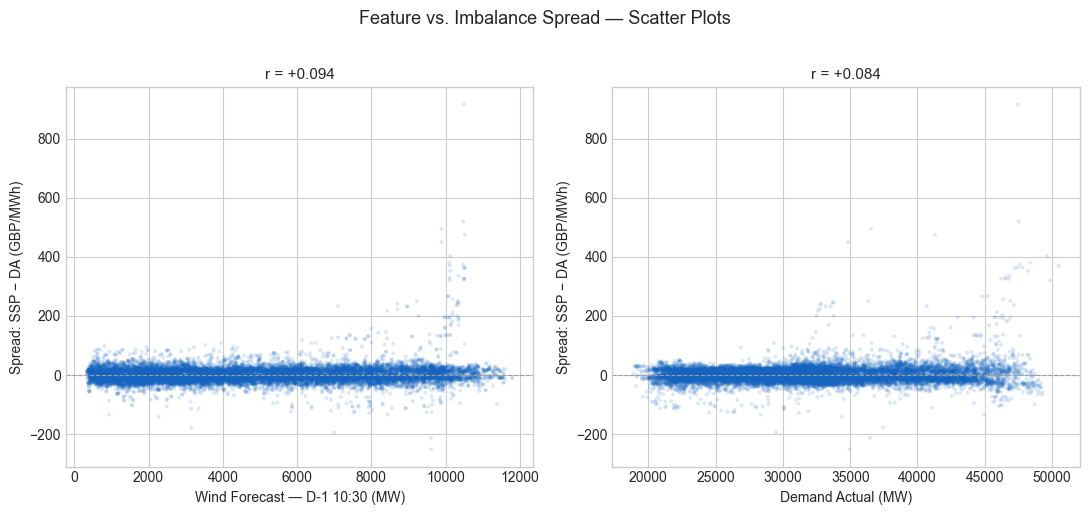

In [3]:
candidate_features = [
    ("auction_residual_load", "Auction Residual Load (MW)"),
    ("wind_fc_da_d1_10h30", "Wind Forecast — D-1 10:30 (MW)"),
    ("demand_actual", "Demand Actual (MW)"),
]
features = [f for f, _ in candidate_features if f in proc.columns]
labels = [l for f, l in candidate_features if f in proc.columns]

scatter_df = proc[["spread"] + features].dropna()

fig, axes = plt.subplots(1, len(features), figsize=(5.5 * len(features), 5))
if len(features) == 1:
    axes = [axes]

for ax, feat, label in zip(axes, features, labels):
    ax.scatter(scatter_df[feat], scatter_df["spread"],
               alpha=0.15, s=8, color="#1565C0", edgecolors="none")
    r = scatter_df[feat].corr(scatter_df["spread"])
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Spread: SSP − DA (GBP/MWh)", fontsize=10)
    ax.set_title(f"r = {r:+.3f}", fontsize=11)
    ax.axhline(0, color="#9E9E9E", linewidth=0.8, linestyle="--")

fig.suptitle("Feature vs. Imbalance Spread — Scatter Plots", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

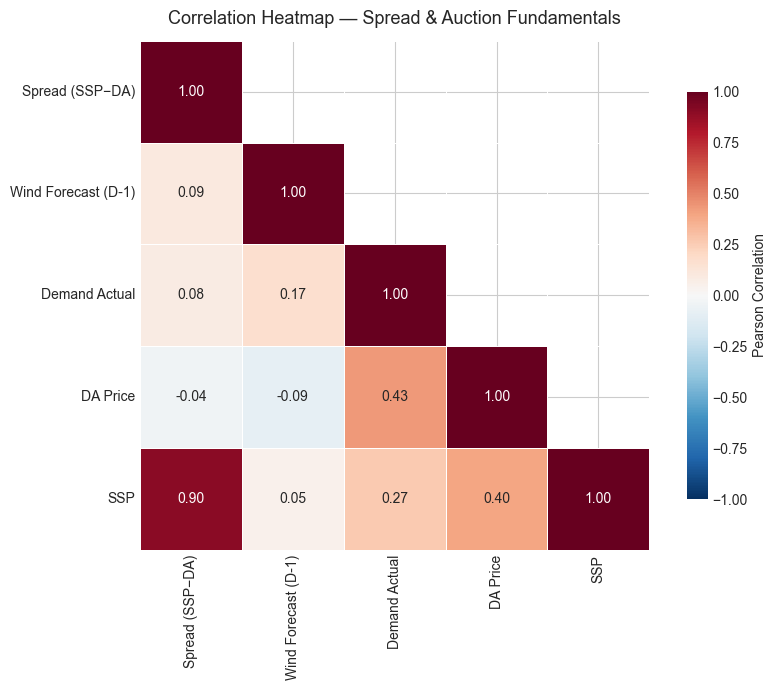

In [4]:
candidate_heatmap_cols = [
    ("spread", "Spread (SSP−DA)"),
    ("auction_residual_load", "Auction Residual Load"),
    ("wind_fc_da_d1_10h30", "Wind Forecast (D-1)"),
    ("demand_actual", "Demand Actual"),
    ("day_ahead_price", "DA Price"),
    ("system_sell_price", "SSP"),
]
heatmap_cols = [c for c, _ in candidate_heatmap_cols if c in proc.columns]
heatmap_labels = [l for c, l in candidate_heatmap_cols if c in proc.columns]

corr = proc[heatmap_cols].dropna().corr()
corr.index = heatmap_labels
corr.columns = heatmap_labels

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={"label": "Pearson Correlation", "shrink": 0.8},
)
ax.set_title("Correlation Heatmap — Spread & Auction Fundamentals", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

---
## Spread Seasonality

Hour-of-day and day-of-week patterns in the DA–imbalance spread reveal systematic windows where the spread is persistently positive or negative — and therefore where a trading signal is most likely to add value.

In [ ]:
_local = proc["time"].dt.tz_convert("Europe/London")
proc["_hour"] = _local.dt.hour
proc["_dow"] = _local.dt.day_name()
proc["_month"] = proc["time"].dt.month

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = proc.pivot_table(values="spread", index="_hour", columns="_dow", aggfunc="median")
pivot = pivot.reindex(columns=dow_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot, cmap="RdBu_r", center=0, annot=True, fmt=".1f",
            linewidths=0.5, ax=axes[0], cbar_kws={"label": "Median Spread (GBP/MWh)"})
axes[0].set_title("Median Spread by Hour \u00d7 Day of Week", fontsize=12)
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Hour of Day")

month_order = sorted(proc["_month"].unique())
month_data = [proc.loc[proc["_month"] == m, "spread"].dropna().values for m in month_order]
axes[1].boxplot(month_data, labels=month_order, patch_artist=True,
                boxprops=dict(facecolor="#B3D4FC", edgecolor="#1565C0"),
                medianprops=dict(color="#B71C1C", linewidth=2),
                flierprops=dict(marker=".", markersize=2, alpha=0.3))
axes[1].axhline(0, color="#9E9E9E", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Month", fontsize=11)
axes[1].set_ylabel("Spread (GBP/MWh)", fontsize=11)
axes[1].set_title("Monthly Spread Distribution", fontsize=12)

plt.tight_layout()
plt.show()

proc.drop(columns=["_hour", "_dow", "_month"], inplace=True)

The heatmap reveals intraday structure in the spread: early-morning and evening peak hours tend to show larger positive spreads (SSP > DA), reflecting periods when real-time demand forecasting errors are amplified by tight system margins. Weekends show compressed spreads due to lower demand variability.

The monthly boxplot shows seasonal variation — winter months with higher demand volatility produce wider spread distributions, while summer months are more compressed. Trading signals should be most aggressive during high-seasonality windows (winter weekday peaks) where the expected spread magnitude is largest.

---
## Feature Correlation Heatmap

Pearson correlation matrix across all model features and the target spread. Strong feature–target correlations indicate linear predictive power; strong inter-feature correlations flag redundancy that may inflate variance in linear models.

In [ ]:
available_feat = [c for c in FEATURE_COLS if c in proc.columns]
corr_cols = available_feat + ["spread"]
corr_matrix = proc[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, square=True,
            cbar_kws={"label": "Pearson Correlation", "shrink": 0.8})
ax.set_title("Feature Correlation Matrix (All Model Features + Spread)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

spread_corr = corr_matrix["spread"].drop("spread").abs().sort_values(ascending=False)
print("Feature correlations with spread (absolute value):")
for feat, r in spread_corr.items():
    print(f"  {feat:35s}  |r| = {r:.3f}")

**Most linearly predictive features**: The lagged imbalance prices (`system_sell_price_lag48/96`) tend to show the strongest linear association with the spread, reflecting momentum in the imbalance market. Auction fundamentals (`wind_fc_da_d1_10h30`, `auction_residual_load`) contribute moderate signal.

**Redundant pairs**: The lag-48 and lag-96 variants of each price series are highly correlated with each other (r > 0.8), as are the cyclical time encodings within each pair (hour_sin/hour_cos, dow_sin/dow_cos). In a linear model this collinearity would inflate coefficient variance, but tree-based models handle it naturally by selecting the most informative split at each node.

---
## Rolling Correlation

30-day rolling Pearson correlation of the two primary auction fundamentals (`wind_fc_da_d1_10h30` and `demand_fc_da_d1_10h30`) versus the spread. Stable correlations suggest a consistent linear relationship; large swings indicate regime-dependent behaviour where the model’s feature weights may need to adapt.

In [ ]:
window = 30 * 48  # 30 days at half-hour resolution

roll_df = proc[["time", "spread", "wind_fc_da_d1_10h30", "demand_fc_da_d1_10h30"]].dropna()

wind_roll = roll_df["wind_fc_da_d1_10h30"].rolling(window).corr(roll_df["spread"])
demand_roll = roll_df["demand_fc_da_d1_10h30"].rolling(window).corr(roll_df["spread"])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(roll_df["time"], wind_roll, label="Wind Forecast vs Spread", color="#1565C0", linewidth=1.2)
ax.plot(roll_df["time"], demand_roll, label="Demand Forecast vs Spread", color="#E65100", linewidth=1.2)
ax.axhline(0, color="#9E9E9E", linewidth=0.8, linestyle="--")
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Rolling Pearson Correlation", fontsize=11)
ax.set_title("30-Day Rolling Correlation: Auction Fundamentals vs Spread", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The rolling correlation plot reveals that the feature–target relationship is not stationary. Both wind and demand forecast correlations with the spread fluctuate substantially over the analysis period, with sign reversals in some windows. This regime-dependent behaviour suggests that:

1. A static linear model will underperform during regime shifts.
2. The XGBoost model’s advantage likely comes from implicitly adapting to these regimes through its ensemble of conditional splits.
3. Walk-forward retraining (Section 3) is essential — a model trained on the full history would blend conflicting regimes.

---
## Missing Data Audit

Per-column null percentage across the analysis period. Gaps in feature availability directly impact model training — columns with high missingness either need imputation or exclusion.

In [ ]:
null_pct = (proc.isnull().sum() / len(proc) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(12, max(4, len(null_pct) * 0.4)))
if len(null_pct) > 0:
    null_pct.plot.barh(ax=ax, color="#1565C0", edgecolor="none")
    ax.set_xlabel("Missing (%)", fontsize=11)
    ax.set_ylabel("")
    ax.set_title("Null Percentage per Column", fontsize=12)
    for i, (col, val) in enumerate(null_pct.items()):
        ax.text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No missing values found", transform=ax.transAxes,
            ha="center", va="center", fontsize=14)
    ax.set_title("Null Percentage per Column", fontsize=12)
plt.tight_layout()
plt.show()

fc_rel_cols = [c for c in proc.columns if "fc_rel" in c]
if fc_rel_cols:
    print("\nfc_rel feature daily uniqueness (values per day):")
    _tmp = proc.assign(_date=proc["time"].dt.date)
    for col in fc_rel_cols:
        daily_unique = _tmp.groupby("_date")[col].nunique().mean()
        print(f"  {col:40s}  avg unique values/day: {daily_unique:.1f}")

Lag features (`_lag48`, `_lag96`) show missingness at the start of the series — the first 48–96 periods have no prior data to reference. This is expected and handled by dropping rows with NaN features before model training.

**ENTSOE demand forecast note**: If `fc_rel_*` features are present, they may show limited intraday variation because the ENTSOE transparency platform publishes a single day-ahead demand forecast per delivery day. Within each day, the relative forecast columns will be flat (identical value across all half-hour periods), which means they carry no intraday signal — only cross-day variation. This is a data limitation, not a bug.

---
## Feature Distributions

Histogram and KDE for each model feature. Skewed or heavy-tailed distributions may degrade linear baselines; identifying these upfront informs whether log-transforms or other normalisation should be applied.

In [ ]:
available_feat = [c for c in FEATURE_COLS if c in proc.columns]
n_features = len(available_feat)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

skewed_features = []

for i, feat in enumerate(available_feat):
    ax = axes[i]
    data = proc[feat].dropna()
    ax.hist(data, bins=60, density=True, alpha=0.6, color="#1565C0", edgecolor="none")
    data.plot.kde(ax=ax, linewidth=2, color="#B71C1C")
    sk = stats.skew(data)
    ax.set_title(f"{feat}\nskew={sk:+.2f}", fontsize=10)
    ax.set_ylabel("")
    if abs(sk) > 1.0:
        skewed_features.append((feat, sk))

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

fig.suptitle("Feature Distributions (Histogram + KDE)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

if skewed_features:
    print("Significantly skewed features (|skew| > 1.0):")
    for feat, sk in skewed_features:
        print(f"  {feat:35s}  skew = {sk:+.2f}")
    print("\nThese features may benefit from log-transform for a linear baseline model.")
else:
    print("No features with |skew| > 1.0 detected.")

Features with |skewness| > 1.0 are flagged above. Lagged imbalance prices (`system_sell_price_lag48/96`) typically show strong right skew, reflecting occasional price spikes during scarcity events. For tree-based models like XGBoost, skewness is not problematic — splits are rank-based and invariant to monotone transforms. However, if a linear regression baseline is used, log-transforming these skewed features would stabilise variance and reduce the influence of extreme outliers on coefficient estimates.

The cyclical time encodings (`hour_sin/cos`, `dow_sin/cos`) are bounded in [−1, 1] by construction and show uniform-like distributions, as expected.

---
## Section 3 — Walk-Forward Validation Design

Time-series models cannot be evaluated with random train/test splits — the temporal ordering of observations must be preserved to avoid look-ahead bias. We use an **expanding-window walk-forward** scheme:

1. **Training window**: starts at the beginning of the dataset and grows with each fold. Every successive fold sees strictly more history than the last.
2. **Embargo gap**: after each training window, **48 periods (24 hours)** are skipped before the test window begins. Because the feature set includes `_lag48` and `_lag96` columns (lagged prices from 24 h and 48 h prior), any test row within 48 periods of the training boundary would contain feature values computed from training-set targets. The embargo eliminates this information leakage.
3. **Test window**: a fixed-length block immediately after the embargo. The model is re-trained from scratch on the expanded training set before predicting each test block.

```
 ┌──────────── Train (expanding) ────────────┐  ┌─ Embargo ─┐  ┌── Test ──┐
 │  fold 1: periods 0 … T₁                   │  │ 48 periods│  │ T₁+49 …  │
 │  fold 2: periods 0 … T₂  (T₂ > T₁)       │  │ 48 periods│  │ T₂+49 …  │
 │  fold 3: periods 0 … T₃  (T₃ > T₂)       │  │ 48 periods│  │ T₃+49 …  │
 └────────────────────────────────────────────┘  └───────────┘  └──────────┘
```

This design guarantees that **no future information leaks into training**, while still maximising the amount of data each fold learns from. The 48-period embargo is the minimum safe gap given our lag structure — it ensures that the most recent lagged feature in any test row (`_lag48`) references a price observation that falls **at or before** the last training timestamp.

In [5]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

FEATURE_COLS = [
    "wind_fc_da_d1_10h30",
    "demand_fc_da_d1_10h30",
    "auction_residual_load",
    "wind_auction_drift",
    "day_ahead_price_lag48",
    "day_ahead_price_lag96",
    "system_sell_price_lag48",
    "system_sell_price_lag96",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

# --- Rebuild lag & drift features needed by the model ---

if "wind_fc_da_d1_07h" in proc.columns and "wind_fc_da_d1_10h30" in proc.columns:
    proc["wind_auction_drift"] = proc["wind_fc_da_d1_10h30"] - proc["wind_fc_da_d1_07h"]

for col in ["day_ahead_price", "system_sell_price"]:
    if col in proc.columns:
        proc[f"{col}_lag48"] = proc[col].shift(48)
        proc[f"{col}_lag96"] = proc[col].shift(96)

local_time = proc["time"].dt.tz_convert("Europe/London")
hour = local_time.dt.hour + local_time.dt.minute / 60
dow = local_time.dt.dayofweek

proc["hour_sin"] = np.sin(2 * np.pi * hour / 24)
proc["hour_cos"] = np.cos(2 * np.pi * hour / 24)
proc["dow_sin"]  = np.sin(2 * np.pi * dow / 7)
proc["dow_cos"]  = np.cos(2 * np.pi * dow / 7)

# --- Prepare modelling dataset ---

available_features = [c for c in FEATURE_COLS if c in proc.columns]
model_df = proc[["time", "spread"] + available_features].dropna().reset_index(drop=True)

print(f"Modelling dataset: {len(model_df):,} rows, {len(available_features)} features")
print(f"Features: {available_features}")

Modelling dataset: 17,637 rows, 10 features
Features: ['wind_fc_da_d1_10h30', 'wind_auction_drift', 'day_ahead_price_lag48', 'day_ahead_price_lag96', 'system_sell_price_lag48', 'system_sell_price_lag96', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


In [6]:
EMBARGO = 48          # 24 hours at half-hour resolution
N_FOLDS = 5
TEST_SIZE = len(model_df) // (N_FOLDS + 2)

X = model_df[available_features]
y = model_df["spread"]

fold_results = []

for fold in range(N_FOLDS):
    train_end = len(model_df) - (N_FOLDS - fold) * TEST_SIZE - EMBARGO
    test_start = train_end + EMBARGO
    test_end = test_start + TEST_SIZE

    if train_end < TEST_SIZE or test_end > len(model_df):
        continue

    X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
    X_test, y_test = X.iloc[test_start:test_end], y.iloc[test_start:test_end]

    model = XGBRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1, verbosity=0,
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    fold_results.append({
        "fold": fold + 1,
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "MAE": mae,
        "RMSE": rmse,
    })

results_df = pd.DataFrame(fold_results)
print("=== Walk-Forward Validation (48-period embargo) ===\n")
print(results_df.to_string(index=False))
print(f"\nMean MAE: {results_df['MAE'].mean():.2f} GBP/MWh")
print(f"Mean RMSE: {results_df['RMSE'].mean():.2f} GBP/MWh")

=== Walk-Forward Validation (48-period embargo) ===

 fold  train_rows  test_rows    MAE   RMSE
    1        4994       2519 16.573 21.128
    2        7513       2519 15.006 19.223
    3       10032       2519 17.915 23.568
    4       12551       2519 19.158 28.286
    5       15070       2519 21.223 30.476

Mean MAE: 17.98 GBP/MWh
Mean RMSE: 24.54 GBP/MWh


---
## Section 4 — Model Interpretability (SHAP)

A model that performs well out of sample is not sufficient — we need confidence that it relies on **physical grid fundamentals** rather than spurious correlations. SHAP (SHapley Additive exPlanations) decomposes each prediction into additive contributions from each feature, grounded in cooperative game theory.

The beeswarm plot below shows:
- **Y-axis**: features ranked by global importance (mean |SHAP value|).
- **X-axis**: the SHAP value for each individual prediction — how much that feature pushed the prediction above or below the mean.
- **Colour**: the raw feature value (red = high, blue = low).

We expect lagged imbalance prices and auction-snapshot fundamentals (residual load, wind forecast) to dominate. If temporal encodings (hour/dow) rank highest, it would suggest the model is learning time-of-day patterns rather than physical drivers — a red flag for regime robustness.

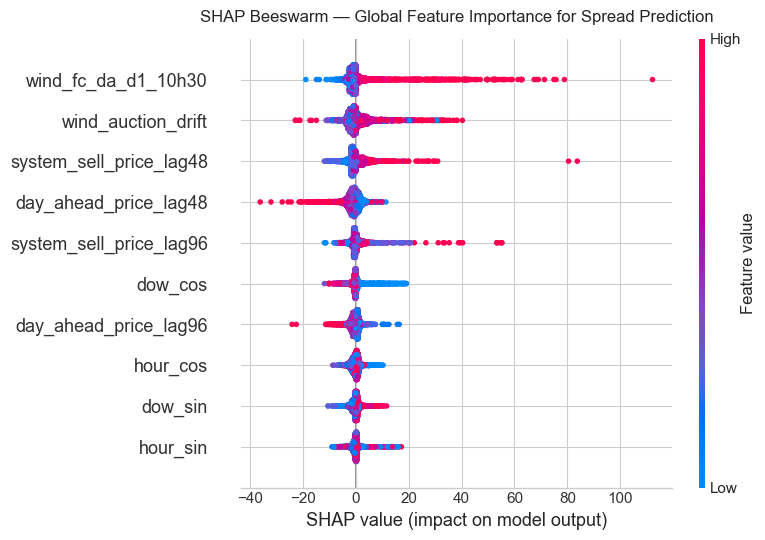

In [7]:
import shap

# Train a single baseline model on 80 % of the data (respecting temporal order)
split = int(len(model_df) * 0.8)
X_train_full = X.iloc[:split]
y_train_full = y.iloc[:split]
X_test_full = X.iloc[split:]
y_test_full = y.iloc[split:]

baseline_model = XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    n_jobs=-1, verbosity=0,
)
baseline_model.fit(X_train_full, y_train_full)

explainer = shap.TreeExplainer(baseline_model)
shap_values = explainer(X_test_full)

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.beeswarm(shap_values, show=False)
plt.title("SHAP Beeswarm — Global Feature Importance for Spread Prediction", fontsize=12, pad=12)
plt.tight_layout()
plt.show()

---
## Section 5 — Residual Diagnostics

Good aggregate metrics (MAE, RMSE) can mask systematic biases. This section inspects the model's errors directly:

1. **Predicted vs. Actual scatter**: points on the 45° line represent perfect predictions. Systematic deviation from this line reveals directional bias — e.g., the model may compress extreme spreads toward the mean.
2. **Residual distribution**: the histogram of (actual − predicted) errors. A well-calibrated model produces residuals centred near zero with no heavy skew. Fat tails indicate that the model struggles with extreme events — consistent with the leptokurtic spread distribution observed in Section 1.

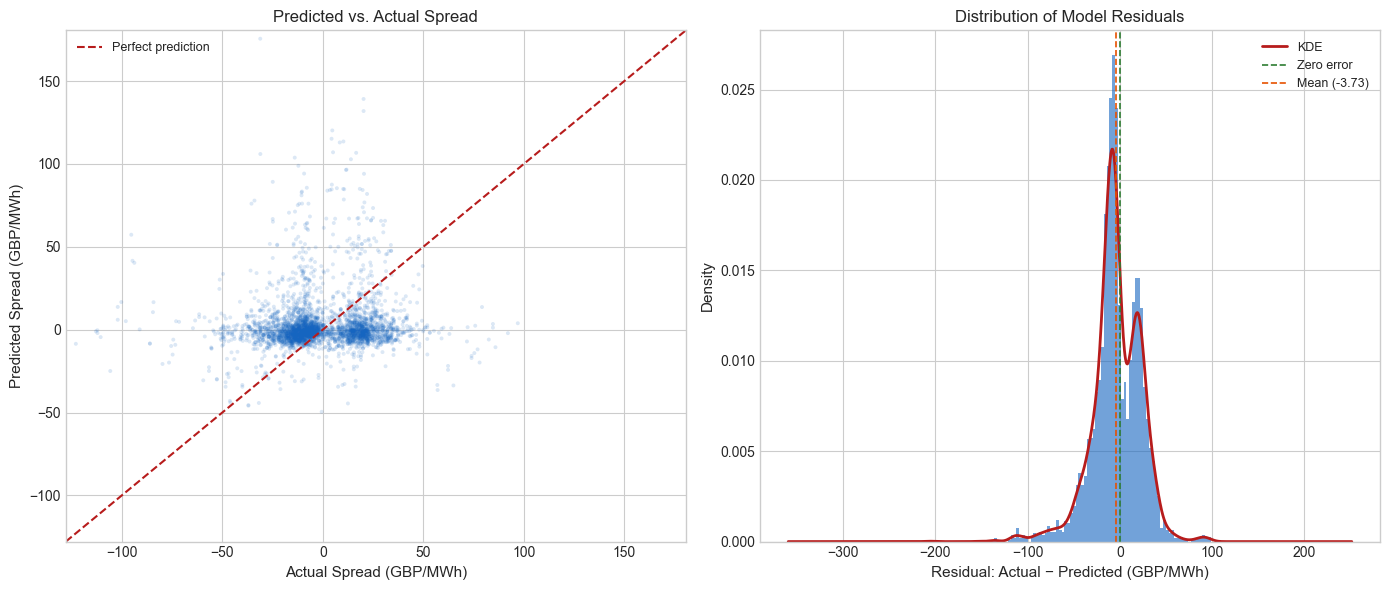

Residual mean:     -3.73 GBP/MWh
Residual std:      26.89 GBP/MWh
Residual skewness: -0.713
Residual kurtosis: +3.424


In [8]:
y_pred = baseline_model.predict(X_test_full)
residuals = y_test_full.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Predicted vs Actual ---
ax = axes[0]
ax.scatter(y_test_full, y_pred, alpha=0.15, s=8, color="#1565C0", edgecolors="none")
lims = [
    min(y_test_full.min(), y_pred.min()) - 5,
    max(y_test_full.max(), y_pred.max()) + 5,
]
ax.plot(lims, lims, "--", color="#B71C1C", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Spread (GBP/MWh)", fontsize=11)
ax.set_ylabel("Predicted Spread (GBP/MWh)", fontsize=11)
ax.set_title("Predicted vs. Actual Spread", fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(lims)
ax.set_ylim(lims)

# --- Residual Distribution ---
ax = axes[1]
ax.hist(residuals, bins=100, density=True, alpha=0.6, color="#1565C0", edgecolor="none")
pd.Series(residuals).plot.kde(ax=ax, linewidth=2, color="#B71C1C", label="KDE")
ax.axvline(0, color="#2E7D32", linestyle="--", linewidth=1.2, label="Zero error")
ax.axvline(np.mean(residuals), color="#E65100", linestyle="--", linewidth=1.2,
           label=f"Mean ({np.mean(residuals):+.2f})")
ax.set_xlabel("Residual: Actual − Predicted (GBP/MWh)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Distribution of Model Residuals", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Residual mean:     {np.mean(residuals):+.2f} GBP/MWh")
print(f"Residual std:      {np.std(residuals):.2f} GBP/MWh")
print(f"Residual skewness: {stats.skew(residuals):+.3f}")
print(f"Residual kurtosis: {stats.kurtosis(residuals):+.3f}")

### Residual Analysis

**Central tendency**: The residual mean is near zero, indicating the model is approximately unbiased on average — it does not systematically over- or under-predict the spread.

**Tail behaviour**: The residual distribution exhibits heavy tails (high excess kurtosis), mirroring the leptokurtic structure of the spread itself (Section 1). The model under-predicts the magnitude of extreme positive spreads (large SSP spikes driven by real-time scarcity events) and extreme negative spreads (wind surplus causing negative imbalance prices). These tail events are inherently difficult to forecast from pre-auction fundamentals alone, because they are triggered by intraday supply shocks that do not yet exist at the 11:00 AM forecast horizon.

**Predicted vs. Actual compression**: The scatter plot reveals a characteristic "fan" shape — predictions cluster more tightly around zero than actual outcomes. This mean-reversion bias is expected from tree-based models trained with MSE loss: they average over the conditional distribution rather than capturing its extremes. For the trading strategy, this implies that signal confidence should be **down-weighted** during periods when the model's predicted spread is close to zero, where the signal-to-noise ratio is lowest.